In [185]:
import pandas as pd
import numpy as np
import csv
import math
from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt

## Summary

I take the actual moves over 9 days, convert them into annualized volatility and then I can compare it to the VIX9D.
$$
RV = 100 \cdot \sqrt{\frac{252}{9} \cdot \sum r^2}
$$

In [158]:
VIX9D_PATH = Path("/Users/jplatta/.schwab_rb/data/history/VIX9D_day.csv")
SPX_PATH = Path("/Users/jplatta/.schwab_rb/data/history/SPX_day.csv")

FORWARD_DAYS = 9
TRADING_DAYS_PER_YEAR = 252
START_DATE = pd.to_datetime("2022-01-01").date()
END_DATE = pd.to_datetime("2026-04-06").date()
ROLLING_WINDOW_DAYS = 3
SHORT_STRIKE_STD_DEVS = 1.5

## Build Dataset

In [155]:
spx_dly = pd.read_csv(SPX_PATH, header=0)
spx_dly.index = pd.to_datetime(spx_dly['datetime']).dt.date
spx_dly.index.name = 'date'

study_df = pd.DataFrame()
study_df['spx_close'] = spx_dly['close']
study_df['log_ret'] = np.log(study_df['spx_close'] / study_df['spx_close'].shift(1))
study_df['rv_3d_pct'] = (
    100 * np.sqrt(
        252 / 3 * study_df['log_ret'].rolling(3).apply(lambda x: (x**2).sum())
    )
)
study_df['rv_9d_fwd_pct'] = (
    100 * np.sqrt(
        252 / 9 * study_df['log_ret'].rolling(9).apply(lambda x: (x**2).sum()).shift(-9)
    )
)
study_df = study_df[study_df.index >= START_DATE]

vix9d_dly = pd.read_csv(VIX9D_PATH, header=0)
vix9d_dly.index = pd.to_datetime(vix9d_dly['datetime']).dt.date
vix9d_dly.index.name = 'date'
vix9d_dly = vix9d_dly[vix9d_dly.index >= START_DATE]

study_df = study_df.join(vix9d_dly[['close']].rename(columns={'close': 'iv'})).dropna()
study_df['iv_rv_spread'] = study_df['iv'] - study_df['rv_9d_fwd_pct']
study_df['iv_rv_3d_spread'] = study_df['iv'] - study_df['rv_3d_pct']

# NOTE: iron condors strikes
study_df['exp_mv_pct'] = study_df['iv'] * np.sqrt(9 / 252)
study_df['exp_mv_pts'] = round(study_df['spx_close'] * study_df['exp_mv_pct'] / 100, 2)
study_df['put_strike'] = study_df['spx_close'] - 2 * study_df['exp_mv_pts']
study_df['call_strike'] = study_df['spx_close'] + 2 * study_df['exp_mv_pts']
study_df['9d_close'] = study_df['spx_close'].shift(-9)
study_df['ITM'] = (study_df['9d_close'] <= study_df['put_strike']) | (study_df['9d_close'] >= study_df['call_strike'])
study_df.loc[study_df['ITM'], 'outcome'] = 0
study_df.loc[study_df['ITM'] == False, 'outcome'] = 1
# study_df.head(20)

## IV and RV Stats

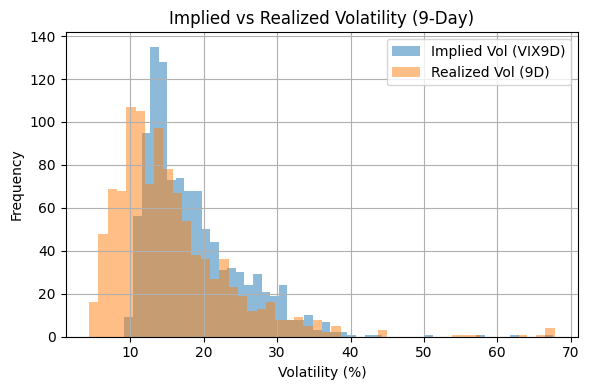

In [229]:
fig, ax = plt.subplots(figsize=(6, 4))

study_df['iv'].hist(bins=50, alpha=0.5, ax=ax, label='Implied Vol (VIX9D)')
study_df['rv_9d_fwd_pct'].hist(bins=50, alpha=0.5, ax=ax, label='Realized Vol (9D)')

ax.set_title('Implied vs Realized Volatility (9-Day)')
ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('iv_vs_rv_hist.png', dpi=100)
plt.show()

In [214]:
study_df.loc[study_df['outcome'] == 1, ['iv', 'rv_9d_fwd_pct', 'iv_rv_spread', 'iv_rv_3d_spread']].mean()

iv                 18.552964
rv_9d_fwd_pct      15.334787
iv_rv_spread        3.218177
iv_rv_3d_spread     3.897313
dtype: float64

In [157]:
study_df.loc[study_df['outcome'] == 0, ['iv', 'rv_9d_fwd_pct', 'iv_rv_spread', 'iv_rv_3d_spread']].mean()

iv                 18.797778
rv_9d_fwd_pct      28.242327
iv_rv_spread       -9.444549
iv_rv_3d_spread     3.667716
dtype: float64

In [168]:
# NOTE: win rate
round(study_df['outcome'].mean(), 2)

np.float64(0.98)

In [169]:
study_df['iv_rv_spread'].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    1057.000000
mean        3.002539
std         6.030866
min       -45.339418
1%        -13.363253
5%         -5.751895
50%         3.605204
95%        10.168305
99%        15.054429
max        24.000357
Name: iv_rv_spread, dtype: float64

(array([20362., 20393., 20423., 20454., 20485., 20513.]),
 [Text(20362.0, 0, '2025-10'),
  Text(20393.0, 0, '2025-11'),
  Text(20423.0, 0, '2025-12'),
  Text(20454.0, 0, '2026-01'),
  Text(20485.0, 0, '2026-02'),
  Text(20513.0, 0, '2026-03')])

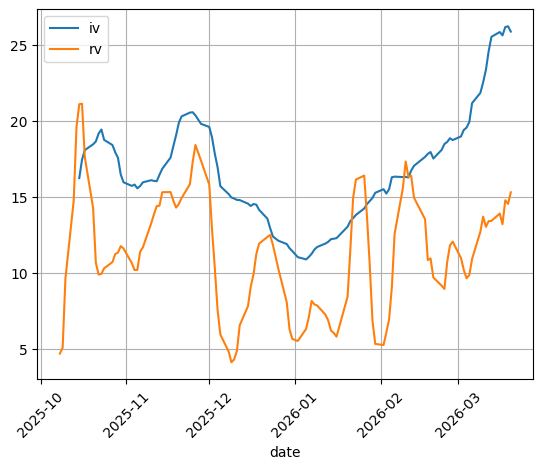

In [218]:
signals_df = pd.DataFrame()
signals_df['iv'] = study_df.loc[study_df.index > pd.to_datetime('2025-10-01').date(), ['iv']].rolling(10).mean()
signals_df['rv'] = study_df.loc[study_df.index > pd.to_datetime('2025-10-01').date(), ['rv_3d_pct']].rolling(5).mean()
signals_df.plot(grid=True)
plt.xticks(rotation=45) 

(array([20362., 20393., 20423., 20454., 20485., 20513.]),
 [Text(20362.0, 0, '2025-10'),
  Text(20393.0, 0, '2025-11'),
  Text(20423.0, 0, '2025-12'),
  Text(20454.0, 0, '2026-01'),
  Text(20485.0, 0, '2026-02'),
  Text(20513.0, 0, '2026-03')])

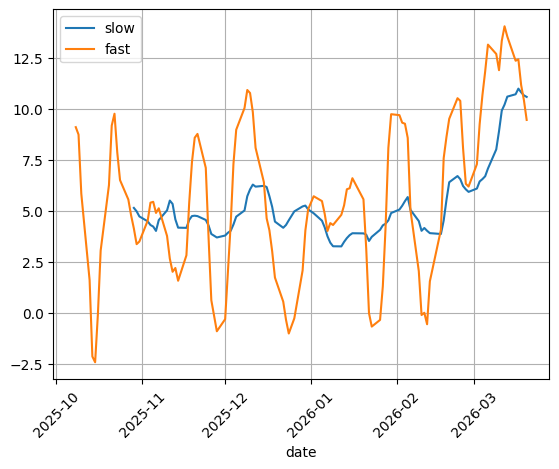

In [220]:
signals_df = pd.DataFrame()
signals_df['slow'] = study_df.loc[study_df.index > pd.to_datetime('2025-10-01').date(), ['iv_rv_3d_spread']].rolling(20).mean()
signals_df['fast'] = study_df.loc[study_df.index > pd.to_datetime('2025-10-01').date(), ['iv_rv_3d_spread']].rolling(5).mean()
signals_df.plot(grid=True)
plt.xticks(rotation=45) 

(array([20393., 20407., 20423., 20437., 20454., 20468., 20485., 20499.,
        20513., 20527.]),
 [Text(20393.0, 0, '2025-11-01'),
  Text(20407.0, 0, '2025-11-15'),
  Text(20423.0, 0, '2025-12-01'),
  Text(20437.0, 0, '2025-12-15'),
  Text(20454.0, 0, '2026-01-01'),
  Text(20468.0, 0, '2026-01-15'),
  Text(20485.0, 0, '2026-02-01'),
  Text(20499.0, 0, '2026-02-15'),
  Text(20513.0, 0, '2026-03-01'),
  Text(20527.0, 0, '2026-03-15')])

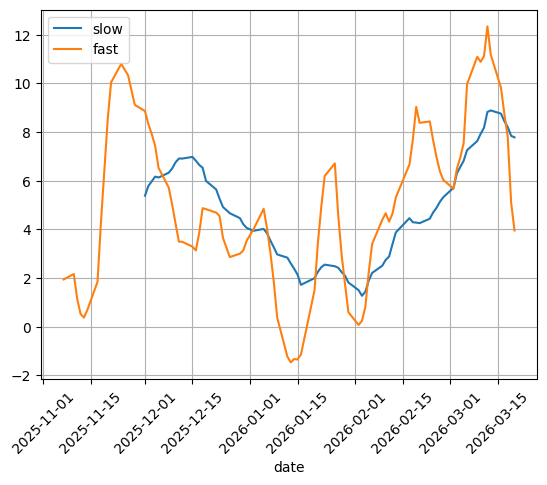

In [203]:
signals_df = pd.DataFrame()
signals_df['slow'] = study_df.loc[study_df.index > pd.to_datetime('2025-11-01').date(), ['iv_rv_spread']].rolling(20).mean()
signals_df['fast'] = study_df.loc[study_df.index > pd.to_datetime('2025-11-01').date(), ['iv_rv_spread']].rolling(5).mean()
signals_df.plot(grid=True)
plt.xticks(rotation=45) 

(array([20407., 20423., 20437., 20454., 20468., 20485., 20499., 20513.,
        20527.]),
 [Text(20407.0, 0, '2025-11-15'),
  Text(20423.0, 0, '2025-12-01'),
  Text(20437.0, 0, '2025-12-15'),
  Text(20454.0, 0, '2026-01-01'),
  Text(20468.0, 0, '2026-01-15'),
  Text(20485.0, 0, '2026-02-01'),
  Text(20499.0, 0, '2026-02-15'),
  Text(20513.0, 0, '2026-03-01'),
  Text(20527.0, 0, '2026-03-15')])

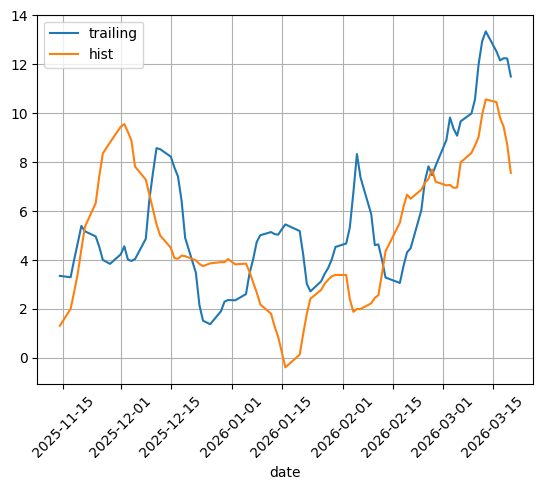

In [204]:
signals_df = pd.DataFrame()
signals_df['trailing'] = study_df.loc[study_df.index > pd.to_datetime('2025-11-01').date(), ['iv_rv_3d_spread']].rolling(10).mean()
signals_df['hist'] = study_df.loc[study_df.index > pd.to_datetime('2025-11-01').date(), ['iv_rv_spread']].rolling(10).mean()
signals_df.plot(grid=True)
plt.xticks(rotation=45) 

(array([20468., 20475., 20485., 20492., 20499., 20506., 20513., 20520.,
        20527., 20534.]),
 [Text(20468.0, 0, '2026-01-15'),
  Text(20475.0, 0, '2026-01-22'),
  Text(20485.0, 0, '2026-02-01'),
  Text(20492.0, 0, '2026-02-08'),
  Text(20499.0, 0, '2026-02-15'),
  Text(20506.0, 0, '2026-02-22'),
  Text(20513.0, 0, '2026-03-01'),
  Text(20520.0, 0, '2026-03-08'),
  Text(20527.0, 0, '2026-03-15'),
  Text(20534.0, 0, '2026-03-22')])

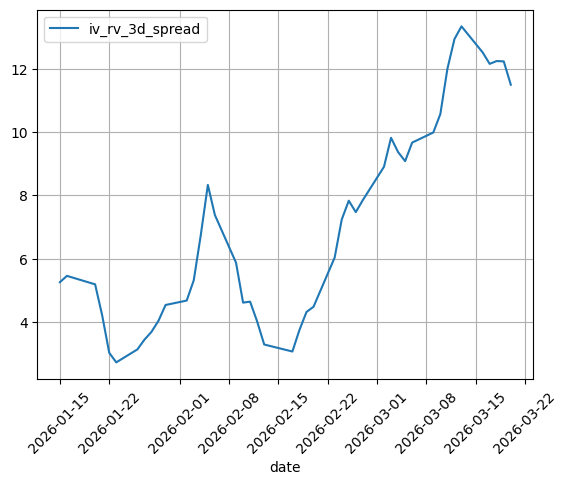

In [189]:
ax = study_df.loc[study_df.index > pd.to_datetime('2026-01-01').date(), ['iv_rv_3d_spread']].rolling(10).mean().plot(grid=True)
plt.xticks(rotation=45) 

(array([20468., 20475., 20485., 20492., 20499., 20506., 20513., 20520.,
        20527., 20534.]),
 [Text(20468.0, 0, '2026-01-15'),
  Text(20475.0, 0, '2026-01-22'),
  Text(20485.0, 0, '2026-02-01'),
  Text(20492.0, 0, '2026-02-08'),
  Text(20499.0, 0, '2026-02-15'),
  Text(20506.0, 0, '2026-02-22'),
  Text(20513.0, 0, '2026-03-01'),
  Text(20520.0, 0, '2026-03-08'),
  Text(20527.0, 0, '2026-03-15'),
  Text(20534.0, 0, '2026-03-22')])

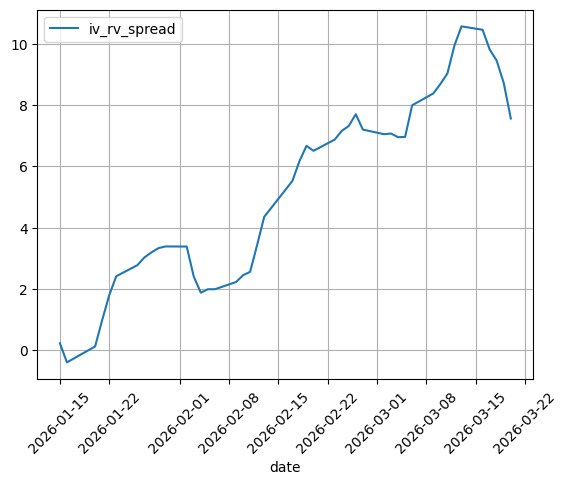

In [187]:
ax = study_df.loc[study_df.index > pd.to_datetime('2026-01-01').date(), ['iv_rv_spread']].rolling(10).mean().plot(grid=True)
plt.xticks(rotation=45) 

## Spread Buckets

In [146]:
study_df['spread_bucket'] = pd.qcut(study_df['iv_rv_spread'], 4)
study_df.groupby('spread_bucket')['outcome'].mean()

/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_89139/4191613761.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  study_df.groupby('spread_bucket')['outcome'].mean()


spread_bucket
(-45.339999999999996, 0.791]    0.935849
(0.791, 3.605]                  0.996212
(3.605, 6.275]                  1.000000
(6.275, 24.0]                   1.000000
Name: outcome, dtype: float64

In [150]:
study_df['iv_rolling_rv_bucket'] = pd.qcut(study_df['iv_rv_3d_spread'], 4)
study_df.groupby('iv_rolling_rv_bucket')['outcome'].mean()

/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_89139/817762194.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  study_df.groupby('iv_rolling_rv_bucket')['outcome'].mean()


iv_rolling_rv_bucket
(-47.522, 0.64]    0.988679
(0.64, 4.489]      0.969697
(4.489, 7.518]     0.981061
(7.518, 25.811]    0.992424
Name: outcome, dtype: float64